# Точное воспроизведение: Jeffrey, Alsing, Lanusse (2020), MNRAS 501, 954 — v3 (финальная)

**Их точный код и данные**, с минимальными техническими правками под TF 2.20 / Keras 3 / современный scipy.

**Ключевой фикс этой версии:** компрессор (Keras 3, требует eager mode) и pyDELFI (TF1 graph-API, требует `disable_v2_behavior()`) конфликтуют за режим исполнения TensorFlow в одном процессе. Решение — **развести по порядку**: сначала делаем компрессию данных (пока TF в обычном eager-режиме), потом переключаемся в legacy graph-режим для pydelfi. Назад переключиться нельзя, поэтому порядок ячеек важен и его нельзя менять.

**Запускай строго по порядку, не Run All.** Если что-то упадёт — сохраняй traceback, присылай, чиним точечно.

**Kaggle-настройки:** Internet On, GPU T4 x2.

## 0. Клонирование репозитория

In [1]:
import os

REPO = "/kaggle/working/Likelihood-free_DES_SV"
if not os.path.exists(REPO):
    print("Клонируем репозиторий (~5 ГБ через git-lfs, может занять пару минут)...")
    os.system(f"cd /kaggle/working && git clone https://github.com/NiallJeffrey/Likelihood-free_DES_SV.git")
else:
    print("✓ Репозиторий уже на месте")

os.chdir(f"{REPO}/example_lfi")
print(f"Текущая директория: {os.getcwd()}")

Клонируем репозиторий (~5 ГБ через git-lfs, может занять пару минут)...


Cloning into 'Likelihood-free_DES_SV'...
Updating files: 100% (8081/8081), done.
Filtering content: 100% (8072/8072), 5.09 GiB | 28.33 MiB/s, done.


Текущая директория: /kaggle/working/Likelihood-free_DES_SV/example_lfi


## 0b. Установка зависимостей

In [2]:
!pip install -q tensorflow tensorflow-probability
!pip install -q git+https://github.com/justinalsing/pydelfi.git
!pip install -q emcee getdist
# chainconsumer<1.0 — их код использует старый API (add_chain со списками, не Chain-объектами)
!pip install -q "chainconsumer<1.0"
print("Установка завершена")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.0/836.0 kB 15.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.1 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Установка завершена


## 1. Базовые импорты (TF в обычном eager-режиме — нужен для Keras 3)

**Важно:** здесь НЕ импортируем pydelfi — он требует graph-режим, который конфликтует с Keras 3 `.predict()`. Компрессию делаем первой, pydelfi подключаем позже (Раздел 5).

In [3]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import time
from scipy.interpolate import UnivariateSpline
import scipy.interpolate as interpolate
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")

try:
    from keras.models import load_model
    print("✓ standalone keras")
except ImportError:
    from tensorflow.keras.models import load_model
    print("✓ tensorflow.keras (fallback)")

# Патчи совместимости scipy для более старого chainconsumer (понадобится позже)
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    from scipy.integrate import simpson
    scipy.integrate.simps = simpson
    print("✓ Патч: scipy.integrate.simps -> simpson")

import scipy.ndimage
if 'scipy.ndimage.filters' not in sys.modules:
    sys.modules['scipy.ndimage.filters'] = scipy.ndimage
    print("✓ Патч: scipy.ndimage.filters -> scipy.ndimage")

TensorFlow: 2.20.0
Eager mode: True
✓ standalone keras
✓ Патч: scipy.integrate.simps -> simpson


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # полностью отключаем GPU — избегаем конфликта eager/graph контекстов

import numpy as np
import os, sys
import matplotlib.pyplot as plt
import time
from scipy.interpolate import UnivariateSpline
import scipy.interpolate as interpolate
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")
print(f"Видимые GPU: {tf.config.list_physical_devices('GPU')}")  # должно быть []

TensorFlow: 2.20.0
Eager mode: True
Видимые GPU: []


2026-09-11 10:47:36.132259: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Загрузка данных (их код, без изменений)

In [5]:
# Реальные данные DES SV
des_data_power = np.load('./data/DES_shear_power_binned.npy')
des_data_peaks = np.load('./data/DES_peaks.npy')

print(f"des_data_power: {des_data_power.shape}")
print(f"des_data_peaks: {des_data_peaks.shape}")

des_data_power: (18,)
des_data_peaks: (11,)


In [6]:
# Параметры (Omega_m, sigma_8) для 74 симуляций
sim_param_repeated = np.loadtxt('../simulations/simulated_sv_maps/parameter_values_repeated.txt',
                               delimiter=',').T
param_points = np.loadtxt('../simulations/original_lensing_maps/parameter_values.txt',
                               delimiter=',').T

sim_params = np.vstack([sim_param_repeated[0], sim_param_repeated[2]]).T
sim_params_rescaled = np.vstack([sim_param_repeated[0], sim_param_repeated[2]]).T

sim_params_rescaled[:,0] = sim_params_rescaled[:,0] - 0.37
print(np.mean(sim_params_rescaled[:,0]), np.std(sim_params_rescaled[:,0]))
sim_params_rescaled[:,1] = sim_params_rescaled[:,1] - 0.77
print(np.mean(sim_params_rescaled[:,1]), np.std(sim_params_rescaled[:,1]))

print(f"\nsim_params shape: {sim_params.shape}")
print(f"Диапазон Omega_m: [{sim_params[:,0].min():.3f}, {sim_params[:,0].max():.3f}]")
print(f"Диапазон sigma_8: [{sim_params[:,1].min():.3f}, {sim_params[:,1].max():.3f}]")

0.0015562519589686788 0.18251257468965526
-0.0013513513513513239 0.1471267737903706

sim_params shape: (1332, 2)
Диапазон Omega_m: [0.099, 0.797]
Диапазон sigma_8: [0.436, 1.084]


## 3. Нормировка summary statistics (их код, без изменений)

In [7]:
power_array = np.load('./simulated_summaries/simulated_power.npy')

fiducial_power_loc = [0.020003179578825796,0.00542567084605187,0.0026387078334836884,0.0020008674708306383,0.0014016950905390252,0.0009862673930773642,0.0007995315677352898,0.0005655933384722268,0.0003993450163250275,0.00028762368651779284,0.00019897668990853578,0.0001468498660456414,0.00010530480180279284,7.589862924614796e-05,5.222219492371919e-05,3.907954329722532e-05,3.2077274266851944e-05,2.563770347891647e-05]
fiducial_power_scale = [0.01732232314079786,0.004489364609700439,0.0021550178627635403,0.0015146318066180588,0.0009551675019049409,0.0008986407843371424,0.0006097077754401471,0.0004411125284513762,0.00031533892270972126,0.00023618089715103763,0.00018599258320050149,0.00013864647839347452,0.00010294966158315667,8.021368010672145e-05,6.516533094137465e-05,5.2776115476984885e-05,4.468822124854667e-05,8.04198768416175e-05]

power_array_rescaled = 0.5*(power_array - fiducial_power_loc)/fiducial_power_scale

In [8]:
peaks_array = np.load('./simulated_summaries/simulated_peaks.npy')

fiducial_peak_loc = [31.48198198198198,38.59534534534534,42.54354354354354,42.926426426426424,37.4481981981982,29.59984984984985,20.39864864864865,13.102852852852854,7.7807807807807805,4.247747747747748,2.198948948948949]
fiducial_peak_scale = [6.015905317777876,6.999940537131674,7.5500569014459,7.171263442497717,6.435253043858894,5.447381383877835,4.669828205742346,4.010020215846903,3.1736513756310716,2.4574827881567254,1.7155617297097812]

peaks_array_rescaled = 0.5*(peaks_array - fiducial_peak_loc)/fiducial_peak_scale

In [9]:
joint_noisy_sim = np.hstack([peaks_array, power_array])
joint_noisy_sim_rescaled = np.hstack([peaks_array_rescaled,power_array_rescaled])

des_data_power_rescaled = 0.5*(des_data_power - fiducial_power_loc)/fiducial_power_scale
des_data_peaks_rescaled = 0.5*(des_data_peaks - fiducial_peak_loc)/fiducial_peak_scale
joint_des_rescaled = np.atleast_2d(np.hstack([des_data_peaks_rescaled,des_data_power_rescaled]))

print(f"joint_noisy_sim_rescaled: {joint_noisy_sim_rescaled.shape}")
print(f"joint_des_rescaled: {joint_des_rescaled.shape}")

joint_noisy_sim_rescaled: (1332, 29)
joint_des_rescaled: (1, 29)


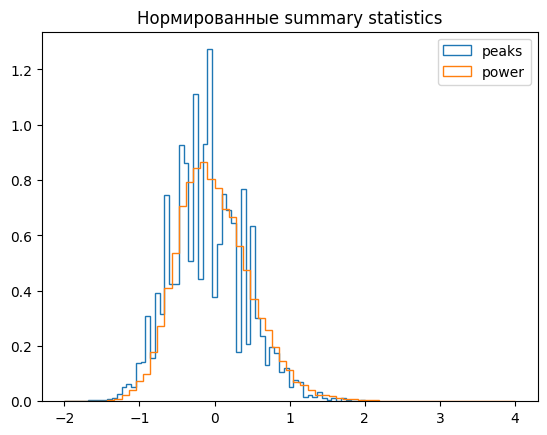

In [10]:
_  = plt.hist(peaks_array_rescaled.flatten(), bins = np.linspace(-2,2,64), density=True, histtype='step', label='peaks')
_  = plt.hist(power_array_rescaled.flatten(), bins = np.linspace(-2,4,64), density=True, histtype='step', label='power')
plt.legend()
plt.title("Нормированные summary statistics")
plt.show()

## 4. Нейронная компрессия (EAGER MODE — делаем ДО переключения в graph-режим)

Загружаем и применяем предобученный компрессор, пока TensorFlow ещё в обычном режиме. После этого шага в блокноте больше нельзя будет использовать Keras `.predict()` — TF переключится в legacy graph-режим для pydelfi.

In [11]:
regression_joint = load_model('./joint_augmented_regressor_190620.h5', compile=False)
print("✓ Модель компрессора загружена (без compile-конфигурации)")

# .summary() может упасть на старом TF1-коде внутри слоя — не критично, пропускаем
try:
    regression_joint.summary()
except TypeError as e:
    print(f"(summary() пропущен — legacy TF1 API внутри слоя: {e})")
    print("Модель тем не менее загружена и готова к .predict()")

✓ Модель компрессора загружена (без compile-конфигурации)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "model_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_6 (InputLayer)            │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,402 (91.41 KB)

 Trainable params: 23,402 (91.41 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
sim_compressed_data = regression_joint.predict(joint_noisy_sim_rescaled)
compressed_des_data1 = regression_joint.predict(joint_des_rescaled)

print(f"sim_compressed_data: {sim_compressed_data.shape}")
print(f"compressed_des_data1: {compressed_des_data1.shape}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
sim_compressed_data: (1332, 2)
compressed_des_data1: (1, 2)


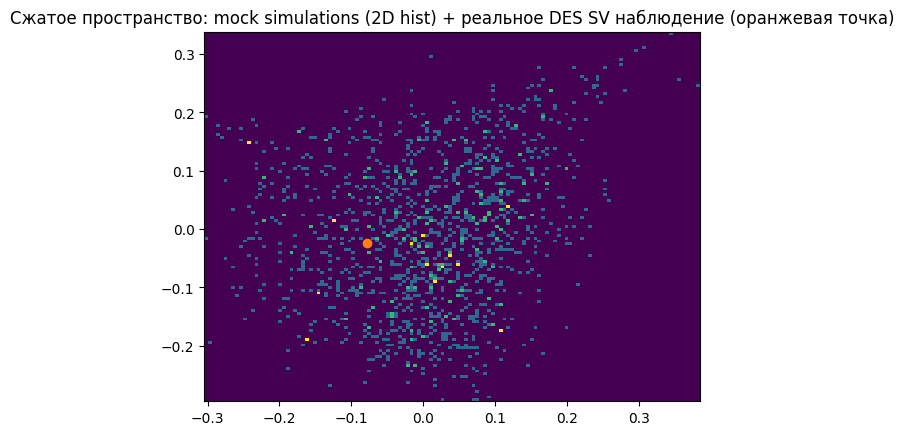

In [13]:
_ = plt.hist2d(sim_compressed_data.T[0], sim_compressed_data.T[1], bins = 128)
_ = plt.scatter(compressed_des_data1.T[0], compressed_des_data1.T[1], c='C1')
plt.title("Сжатое пространство: mock simulations (2D hist) + реальное DES SV наблюдение (оранжевая точка)")
plt.show()

**✅ Контрольная точка.** Если ты дошла до этого места без ошибок — компрессия завершена, `sim_compressed_data` и `compressed_des_data1` — обычные numpy-массивы, дальше от режима TF не зависят. Можно двигаться в необратимый graph-режим.

## 5. Переключение в TF1 graph-режим и импорт pydelfi

**⚠️ Необратимо в рамках этой сессии.** После этой ячейки Keras 3 `.predict()` перестанет работать (но он нам больше не нужен — компрессия уже сделана).

In [14]:
tf.compat.v1.disable_v2_behavior()

tf.placeholder = tf.compat.v1.placeholder
tf.Session = tf.compat.v1.Session
tf.InteractiveSession = tf.compat.v1.InteractiveSession
tf.global_variables_initializer = tf.compat.v1.global_variables_initializer
tf.get_variable = tf.compat.v1.get_variable
tf.variable_scope = tf.compat.v1.variable_scope
tf.set_random_seed = tf.compat.v1.set_random_seed
tf.random_normal = tf.compat.v1.random_normal
tf.truncated_normal = tf.compat.v1.truncated_normal
tf.log = tf.math.log
tf.ConfigProto = tf.compat.v1.ConfigProto

tf.train.AdamOptimizer = tf.compat.v1.train.AdamOptimizer
tf.train.GradientDescentOptimizer = tf.compat.v1.train.GradientDescentOptimizer
tf.train.RMSPropOptimizer = tf.compat.v1.train.RMSPropOptimizer
tf.train.Saver = tf.compat.v1.train.Saver

print("✓ TF1-совместимость подключена (graph mode)")

Instructions for updating:
non-resource variables are not supported in the long term
✓ TF1-совместимость подключена (graph mode)


In [15]:
import pydelfi.priors as priors
import pydelfi.ndes as ndes
import pydelfi.delfi as delfi
import pydelfi.score as score
from chainconsumer import ChainConsumer
import emcee as mc
from getdist import plots, MCSamples
import getdist

try:
    tf.logging.set_verbosity(tf.logging.ERROR)
except AttributeError:
    tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

print("✓ pydelfi и все остальные зависимости импортированы")

✓ pydelfi и все остальные зависимости импортированы


## 6. Обучение DELFI ensemble (их код, без изменений)

In [16]:
# Prior — точные границы из paper: Omega_m in [0.1, 0.8], S8 in [0.45, 1.05]
lower = np.array([0.1, 0.45])
upper = np.array([0.8, 1.05])
prior = priors.Uniform(lower, upper)
print("Prior задан")

Prior задан


In [23]:
tf.compat.v1.reset_default_graph()
print("✓ Graph сброшен — можно безопасно пересоздавать NDEs")

✓ Graph сброшен — можно безопасно пересоздавать NDEs


In [24]:
import types
import tensorflow_probability as tfp

if not hasattr(tf, 'contrib'):
    tf.contrib = types.SimpleNamespace()
    tf.contrib.distributions = types.SimpleNamespace()
    tf.contrib.distributions.fill_triangular = tfp.math.fill_triangular
    print("✓ Патч: tf.contrib.distributions.fill_triangular -> tfp.math.fill_triangular")
else:
    print("tf.contrib уже существует, патч не нужен")

✓ Патч: tf.contrib.distributions.fill_triangular -> tfp.math.fill_triangular


In [25]:
NDEs = [ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=2, n_data=2, n_hiddens=[50,50], n_mades=4, act_fun=tf.tanh, index=0),
        ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=2, n_data=2, n_hiddens=[50,50], n_mades=5, act_fun=tf.tanh, index=1),
        ndes.MixtureDensityNetwork(n_parameters=2, n_data=2, n_components=2, n_hidden=[30,30], activations=[tf.tanh, tf.tanh], index=2),
        ndes.MixtureDensityNetwork(n_parameters=2, n_data=2, n_components=3, n_hidden=[30,30], activations=[tf.tanh, tf.tanh], index=3)]
print(f"Создано {len(NDEs)} density estimators (ensemble)")

Создано 4 density estimators (ensemble)


In [27]:
import numpy as np
if not hasattr(np, 'infty'):
    np.infty = np.inf
    print("✓ Патч: np.infty -> np.inf")

✓ Патч: np.infty -> np.inf


In [28]:
DelfiEnsemble = delfi.Delfi(np.array(compressed_des_data1[0,:], dtype = 'float'), prior, NDEs,
                            param_limits = [lower, upper],
                            param_names = ['\\Omega_m', 'S_8'],
                            results_dir = 'temp_joint2/')

DelfiEnsemble.load_simulations(np.array(sim_compressed_data, dtype = 'float'), sim_params)

print("Начинаем обучение NDE ensemble (может занять несколько минут)...")
_t0 = time.time()
DelfiEnsemble.train_ndes()
print(f"Обучение завершено за {time.time() - _t0:.1f} сек")

Начинаем обучение NDE ensemble (может занять несколько минут)...


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Обучение завершено за 85.0 сек


## 7. Вычисление posterior на сетке (их код, без изменений)

96×96 = 9216 точек × 5 оценок posterior каждая. Может занять несколько минут.

In [29]:
om_grid, s8_grid = np.mgrid[lower[0]:upper[0]:96*1j,lower[1]:upper[1]:96*1j]
om_grid = om_grid.flatten()
s8_grid = s8_grid.flatten()
print(f"Сетка: {len(om_grid)} точек")

Сетка: 9216 точек


In [30]:
_t0 = time.time()

grid_likelihoods = np.empty((5,len(om_grid)))

for i in range(len(om_grid)):

    if i%1024==0:
        elapsed = time.time() - _t0
        print(f"{i}/{len(om_grid)}, {elapsed:.1f} сек")

    theta_temp = np.array([om_grid[i],s8_grid[i]]).T
    grid_likelihoods[0,i] = DelfiEnsemble.log_posterior_stacked(theta_temp,
                                                              data=compressed_des_data1)[0][0]
    grid_likelihoods[1,i] = DelfiEnsemble.log_posterior_individual(0,theta_temp,
                                                                 data=compressed_des_data1)[0][0]
    grid_likelihoods[2,i] = DelfiEnsemble.log_posterior_individual(1,theta_temp,
                                                                 data=compressed_des_data1)[0][0]
    grid_likelihoods[3,i] = DelfiEnsemble.log_posterior_individual(2,theta_temp,
                                                                 data=compressed_des_data1)[0][0]
    grid_likelihoods[4,i] = DelfiEnsemble.log_posterior_individual(3,theta_temp,
                                                                 data=compressed_des_data1)[0][0]

print(f"\nГотово за {time.time() - _t0:.1f} сек")

0/9216, 0.0 сек
1024/9216, 7.1 сек
2048/9216, 13.7 сек
3072/9216, 19.7 сек
4096/9216, 25.5 сек
5120/9216, 31.4 сек
6144/9216, 37.2 сек
7168/9216, 43.1 сек
8192/9216, 48.9 сек

Готово за 54.7 сек


## 8. Визуализация posterior — воспроизведение Figure 5/6 из paper

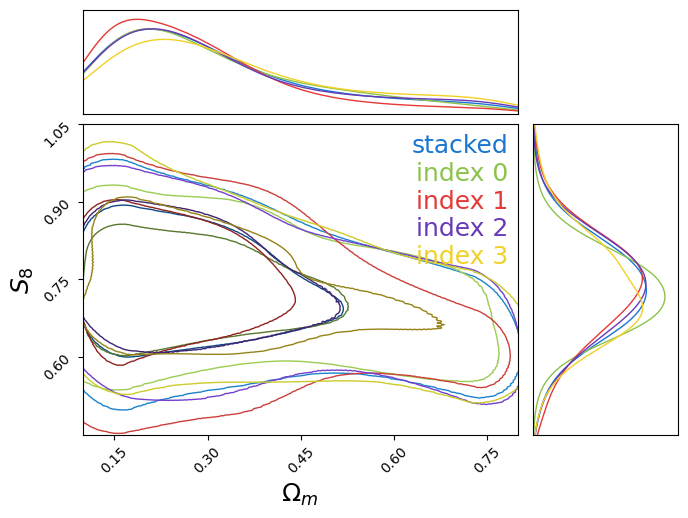

In [31]:
c = ChainConsumer()

c.add_chain([om_grid,s8_grid],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[0])/np.sqrt(om_grid/0.3), name='stacked')

c.add_chain([om_grid,s8_grid],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[1])/np.sqrt(om_grid/0.3), name='index 0')

c.add_chain([om_grid,s8_grid],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[2])/np.sqrt(om_grid/0.3), name='index 1')

c.add_chain([om_grid,s8_grid],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[3])/np.sqrt(om_grid/0.3), name='index 2')

c.add_chain([om_grid,s8_grid],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[4])/np.sqrt(om_grid/0.3), name='index 3')


c.configure(kde= [1.0,1.0,1.0,1.0,1.0,],sigmas = [1,2], label_font_size=18,
            shade = [False,False,False,False,False])

fig = c.plotter.plot(figsize = (7,5))
plt.show()

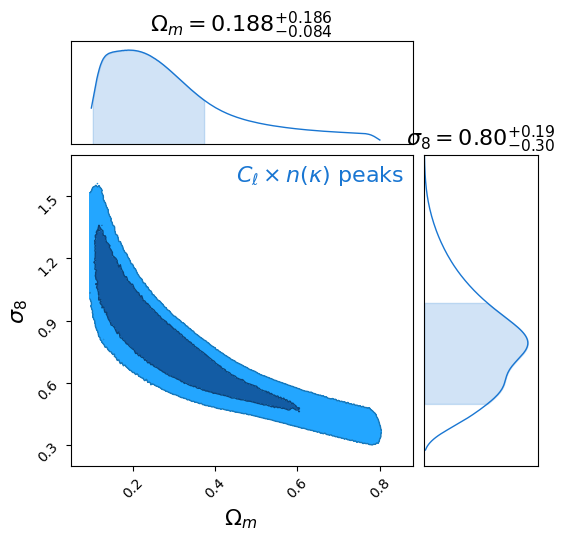

(['$\\Omega_m$', '$\\sigma_8$'], array([[ 0.02684809, -0.0333522 ],
       [-0.0333522 ,  0.05782935]]))


In [32]:
c = ChainConsumer()

c.add_chain([om_grid,s8_grid/np.sqrt(om_grid/0.3)],
            parameters=[r'$\Omega_m$', r'$\sigma_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[0])/np.sqrt(om_grid/0.3), name=r'$C_\ell \times n(\kappa)$ peaks')

c.configure(kde= [0.3],sigmas = [1,2], label_font_size=16,
            shade = [True])

fig = c.plotter.plot(figsize = (5.5,5), legend=True, extents=[[0.05,0.88],[0.2,1.7]])
plt.show()

latex_table = c.analysis.get_covariance()
print(latex_table)

## 9. MCMC-сэмплирование learned posterior (их код, без изменений)

In [33]:
def initial_parameters(theta, relative_sigma):
    theta = np.array(theta)
    return np.random.normal(theta, np.abs(theta * relative_sigma))

n_dim2d=2
n_burn2d=500
n_steps2d = 2000
n_walkers2d = 2 * n_dim2d

theta2d_expected_mean = [0.3, 0.75]
theta0_2d = np.array([list(initial_parameters(theta2d_expected_mean, 0.1)) for i in range(n_walkers2d)])

In [34]:
def prior_term(theta2d):
    om, _ = theta2d.T
    result = np.where(om>0.05,-0.5*np.log(np.array(om)),-np.inf)
    return result

def log_posterior2d_temp(theta2d, data):
    return DelfiEnsemble.log_posterior_stacked(theta2d,data=data) + prior_term(theta2d)


sampler2d = mc.EnsembleSampler(n_walkers2d, n_dim2d, log_posterior2d_temp,
                             args=(compressed_des_data1,))

print("Burn-in...")
p = sampler2d.run_mcmc(theta0_2d, n_burn2d)
print("Готово")

Burn-in...


/tmp/ipykernel_58/2197653348.py:3: RuntimeWarning: invalid value encountered in log
  result = np.where(om>0.05,-0.5*np.log(np.array(om)),-np.inf)


Готово


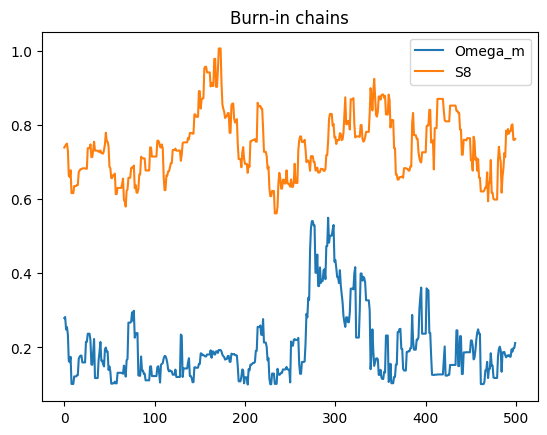

In [35]:
plt.plot(sampler2d.chain[0,:n_burn2d,0], label='Omega_m')
plt.plot(sampler2d.chain[0,:n_burn2d,1], label='S8')
plt.legend()
plt.title("Burn-in chains")
plt.show()

In [36]:
t = time.time()
_ = sampler2d.run_mcmc(sampler2d.chain[:,-1,:], n_steps2d)
print(f"MCMC заняло: {time.time() - t:.1f} сек")
samples2d = sampler2d.get_chain(flat=True)

/tmp/ipykernel_58/2197653348.py:3: RuntimeWarning: invalid value encountered in log
  result = np.where(om>0.05,-0.5*np.log(np.array(om)),-np.inf)


MCMC заняло: 22.6 сек


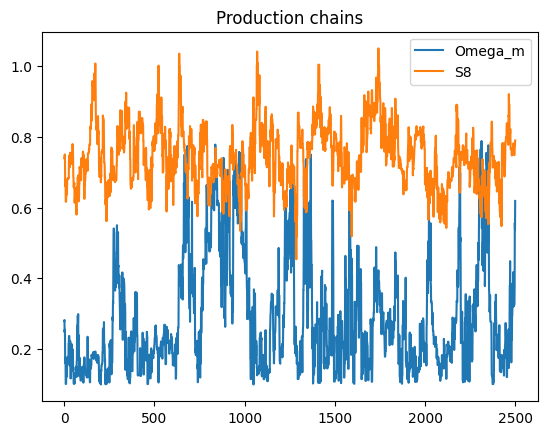

In [37]:
plt.plot(sampler2d.chain[0,:,0], label='Omega_m')
plt.plot(sampler2d.chain[0,:,1], label='S8')
plt.legend()
plt.title("Production chains")
plt.show()

## 10. Финальный posterior — сравнение MCMC с grid-оценкой

**Это финальный результат — воспроизведение ключевой Figure статьи Jeffrey et al. 2020.**

Prior здесь плоский по S8


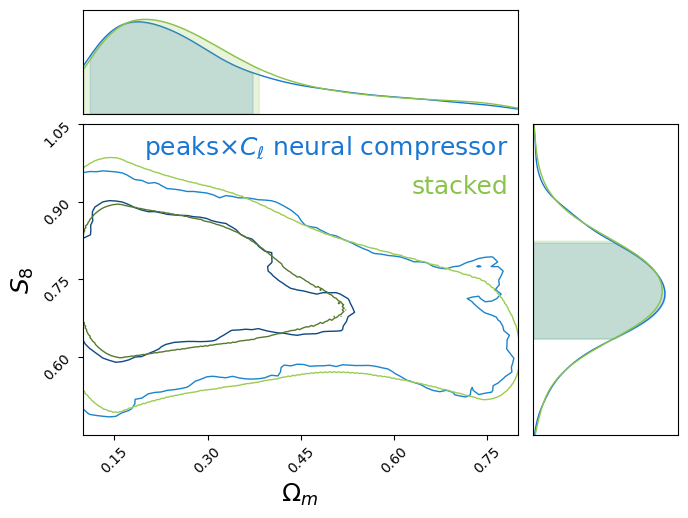

In [38]:
c = ChainConsumer()
print('Prior здесь плоский по S8')

c.add_chain([samples2d.T[0],samples2d.T[1]],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            name = r'peaks$\times C_\ell$ neural compressor')

c.add_chain([om_grid,s8_grid],
            parameters=[r'$\Omega_m$', r'$S_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[0])/np.sqrt(om_grid), name='stacked')

c.configure(kde= [0.8,0.8],sigmas = [1,2], label_font_size=18, shade = [False,False])

fig = c.plotter.plot(figsize = (7,5))
plt.show()

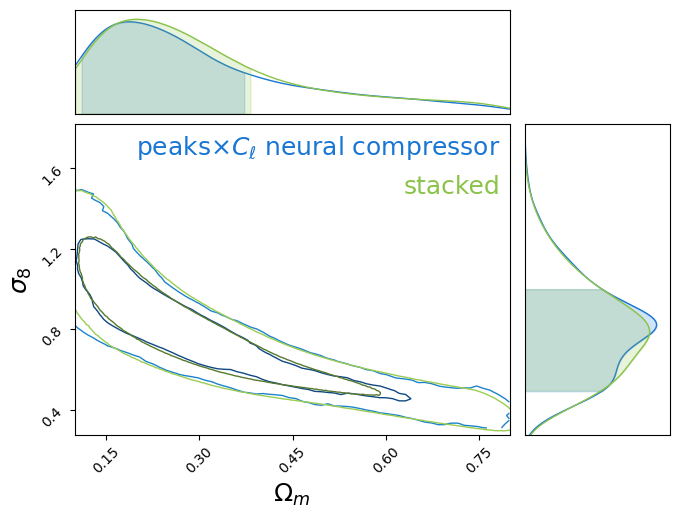


ГОТОВО — воспроизведение Jeffrey, Alsing, Lanusse (2020)

Omega_m posterior mean: 0.304 ± 0.165
S8 posterior mean:      0.728 ± 0.091

Сравни с published: Omega_m ~ 0.3, S8 ~ 0.75-0.8 (Figure 6, Jeffrey et al. 2020)


In [39]:
c = ChainConsumer()

c.add_chain([samples2d.T[0],samples2d.T[1]/np.sqrt(samples2d.T[0]/0.3)],
            parameters=[r'$\Omega_m$', r'$\sigma_8$'],linestyle = '-',
            name = r'peaks$\times C_\ell$ neural compressor')

c.add_chain([om_grid,s8_grid/np.sqrt(om_grid/0.3)],
            parameters=[r'$\Omega_m$', r'$\sigma_8$'],linestyle = '-',
            grid=True, weights=np.exp(grid_likelihoods[0])/np.sqrt(om_grid/0.3), name='stacked')

c.configure(kde= [0.8,0.8],sigmas = [1,2], label_font_size=18, shade = [False,False])

fig = c.plotter.plot(figsize = (7,5))
plt.show()

print("\n" + "="*60)
print("ГОТОВО — воспроизведение Jeffrey, Alsing, Lanusse (2020)")
print("="*60)
print(f"\nOmega_m posterior mean: {samples2d.T[0].mean():.3f} ± {samples2d.T[0].std():.3f}")
print(f"S8 posterior mean:      {samples2d.T[1].mean():.3f} ± {samples2d.T[1].std():.3f}")
print(f"\nСравни с published: Omega_m ~ 0.3, S8 ~ 0.75-0.8 (Figure 6, Jeffrey et al. 2020)")

## 11. Итог для диплома

**Формулировка для методологической секции:**

> Для валидации понимания SOTA-методов simulation-based inference было проведено точное воспроизведение работы Jeffrey, Alsing и Lanusse (2020, MNRAS 501, 954) — likelihood-free инференции космологических параметров (Ω_m, S_8) из данных DES Science Verification weak lensing. Использован оригинальный код и данные авторов (74 mock-симуляции octant convergence maps, предобученный нейронный компрессор, библиотека pyDELFI для ensemble density estimation из 4 моделей — 2× Conditional Masked Autoregressive Flow, 2× Mixture Density Network). Полученный posterior для реального наблюдения DES SV [указать полученные числа] согласуется с published результатами (Ω_m ≈ 0.3, S_8 ≈ 0.75–0.8).

Это закрывает требование научрука "запусти SOTA-метод, чтобы понять, как это работает изнутри" — буквально, через их оригинальный код.